## Imports and Setup

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path

# Go up two levels: notebooks/ -> profile_analyzer/ -> hmm/
# The hmm/ directory contains the profile_analyzer module
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from profile_analyzer import HMMClassificationAnalyzer, HMMVisualizationPlotter

# HMM Classification Analysis: N vs P

**Objective:** Analyze misclassification patterns between amino acids C (Cysteine) and D (Aspartic acid) to understand why the HMM fails on certain traces.

**Date:** December 16, 2024

**Approach:**
1. Load 20-way classification results and identify misclassifications
2. Compare with circle test (baseline) to find systematic failures
3. Analyze skip patterns in critical segment regions (10-25)
4. Generate KDE visualizations to understand distribution differences

## Data Loading
Loading all required data sources:
- 20-way classification results
- Circle test results (amino acids vs their own profiles)
- Segment data (cleaned signal segments)
- Profile data (HMM emission profiles)

### Config

In [2]:
RESULTS_FILE = '/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/test_altered_h/results_20way_barycenter_scale1.0_20251216_120722.json'
H_CIRCLE_TEST_FILE = '/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/test_altered_h_circular/results_20way_barycenter_scale1.0_20251216_120918.json'
N_CIRCLE_TEST_FILE = '/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/Updated_N_Circle_Test/results_20way_segment_20251216_104017.json'

CIRCLE_TEST_FILE = H_CIRCLE_TEST_FILE
SEGMENT_PICKLE = '/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/data/denoise_segment_dynp_parallel_34_BkP_full_pastor_norm_features_clean_1751_4570_min_size_30_length_iqr_25_75_pretty_25_per_aa.pkl'
PROFILE_CSV = '/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/data/altered_H_PASTOR_test_df.csv'

TARGET_AAS = ['H']
SEGMENT_RANGE = (5, 30)

### Initialize Analyzer and Load Data

In [3]:
analyzer = HMMClassificationAnalyzer(
    results_file=RESULTS_FILE,
    target_aas=TARGET_AAS,
    verbose=True
)

(analyzer
 .load_and_clean()
 .filter_keys()
 .find_misclassified()
 .load_circle_test(CIRCLE_TEST_FILE)
 .match_circle_to_misclassified()
 .load_segment_data(SEGMENT_PICKLE)
 .zscore_normalize_segments()
 .load_profiles(PROFILE_CSV, load_all_aas=True))

Initialized analyzer for amino acids: ['H']

Loading results from /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/test_altered_h/results_20way_barycenter_scale1.0_20251216_120722.json
Filtered to 25 traces for target amino acids
Filtered 25 traces to keep keys: ['full_path', 'amino_acid', 'predicted_category', 'log_probability']

Finding misclassified traces...
Found 22 misclassified traces

Misclassification distribution:
  H -> E: 2 traces
  H -> F: 5 traces
  H -> I: 1 traces
  H -> L: 1 traces
  H -> N: 1 traces
  H -> R: 1 traces
  H -> S: 5 traces
  H -> T: 1 traces
  H -> V: 3 traces
  H -> W: 2 traces

Loading circle test results from /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/test_altered_h_circular/results_20way_barycenter_scale1.0_20251216_120918.json
Filtered to 25 circle test traces

Matching misclassified traces with circle test data...
Successfully matched 22 traces

Example log probability comparison:
  Trac

## Initial Exploration

Let's look at the confusion patterns to understand what we're dealing with.

### Examing Confusion Pairs

In [4]:
# Cell 4: Examine confusion patterns
confusion_pairs = analyzer.get_confusion_pairs()

print("Misclassification summary:")
for (true_aa, pred_aa), traces in confusion_pairs.items():
    print(f"  {true_aa} misclassified as {pred_aa}: {len(traces)} traces")

Misclassification summary:
  H misclassified as L: 1 traces
  H misclassified as F: 5 traces
  H misclassified as S: 5 traces
  H misclassified as I: 1 traces
  H misclassified as R: 1 traces
  H misclassified as V: 3 traces
  H misclassified as E: 2 traces
  H misclassified as T: 1 traces
  H misclassified as W: 2 traces
  H misclassified as N: 1 traces


In [5]:
analyzer.debug_emitting_state_counts()


Debugging emitting state counts in paths...

Trace ID                                 | Segs | Circle (M+I) | Misclass (M+I)
------------------------------------------------------------------------------------------
20221011_run02_a_254.0_3531_H            |   35 | 35+ 0=35 | 35+ 0=35
20221221_run01_a_324.0_8887_H            |   35 | 35+ 0=35 | 35+ 0=35
20221107_run01_a_408.0_4085_H            |   35 | 35+ 0=35 | 35+ 0=35
20221107_run01_a_192.0_4071_H            |   35 | 35+ 0=35 | 35+ 0=35
20220824_run02_a_457.0_633_H             |   35 | 34+ 1=35 | 34+ 1=35
20220824_run02_a_324.0_409_H             |   35 | 35+ 0=35 | 35+ 0=35
20221011_run02_a_262.0_3559_H            |   35 | 34+ 1=35 | 34+ 1=35
20220824_run02_a_382.0_493_H             |   35 | 35+ 0=35 | 35+ 0=35
20221107_run01_a_178.0_4015_H            |   35 | 34+ 1=35 | 34+ 1=35
20221108_run01_a_235.0_4323_H            |   35 | 35+ 0=35 | 35+ 0=35
20220824_run02_a_22.0_3_H                |   35 | 35+ 0=35 | 35+ 0=35
20221011_run0

## Visualization Setup

Initialize the plotter with seaborn styling for better-looking plots.

## Skip Pattern Analysis

Comparing which states in the critical region (10-25) are skipped in:
- Circle test (baseline - should be minimal skipping)
- Misclassified runs (problematic cases)

This will help identify if the HMM is systematically avoiding certain states.

### Observations from skip patterns:

Need to double check that the segment indices are correct, because there are a few dots right on the mean of a given profile, and I'm not sure the analysis is correct for these.

- Which states are skipped more frequently?
- Is there a difference between circle test and misclassified?
- Any patterns or clusters?

### Detailed Skip Analysis

In [6]:
skip_analysis_full = analyzer.analyze_skip_patterns((0, 34))

traces_with_skips_full = {
    trace_id: analysis 
    for trace_id, analysis in skip_analysis_full.items() 
    if analysis['circle_skipped']
}

print(f"\nFull range (0-34) analysis:")
print(f"Found {len(traces_with_skips_full)} traces with skipped states")

from collections import Counter
all_skipped_states = []
for analysis in traces_with_skips_full.values():
    all_skipped_states.extend(analysis['circle_skipped'])

skip_distribution = Counter(all_skipped_states)
print(f"\nSkip distribution across all states:")
for state, count in sorted(skip_distribution.items()):
    print(f"  State {state}: skipped {count} times")


Analyzing skip patterns for segment range (0, 34)
Completed skip pattern analysis for 22 traces
Total states skipped in circle tests: 47
Total states skipped in misclassified: 47

Full range (0-34) analysis:
Found 18 traces with skipped states

Skip distribution across all states:
  State 3: skipped 3 times
  State 4: skipped 2 times
  State 5: skipped 3 times
  State 6: skipped 1 times
  State 8: skipped 2 times
  State 9: skipped 2 times
  State 10: skipped 1 times
  State 11: skipped 2 times
  State 12: skipped 1 times
  State 14: skipped 2 times
  State 15: skipped 4 times
  State 16: skipped 2 times
  State 17: skipped 1 times
  State 24: skipped 1 times
  State 30: skipped 3 times
  State 31: skipped 5 times
  State 32: skipped 4 times
  State 33: skipped 4 times
  State 34: skipped 4 times


In [7]:
# Cell 6: Analyze specific segment range
skip_analysis = analyzer.analyze_skip_patterns(SEGMENT_RANGE)

traces_with_skips = {
    trace_id: analysis 
    for trace_id, analysis in skip_analysis.items() 
    if analysis['circle_skipped'] or analysis['misclass_skipped']
}

print(f"\nFound {len(traces_with_skips)} traces with skipped states in range {SEGMENT_RANGE}")
print(f"(out of {len(skip_analysis)} total traces)\n")

if traces_with_skips:
    print("Traces WITH skip patterns:\n")
    for trace_id, analysis in list(traces_with_skips.items())[:10]:
        print(f"{trace_id}:")
        print(f"  True: {analysis['true_aa']} -> Predicted: {analysis['predicted_aa']}")
        print(f"  Circle skipped: {analysis['circle_skipped']}")
        print(f"  Misclass skipped: {analysis['misclass_skipped']}")
        print(f"  Both skipped: {analysis['both_skipped']}\n")


Analyzing skip patterns for segment range (5, 30)
Completed skip pattern analysis for 22 traces
Total states skipped in circle tests: 25
Total states skipped in misclassified: 25

Found 15 traces with skipped states in range (5, 30)
(out of 22 total traces)

Traces WITH skip patterns:

20221011_run02_a_254.0_3531_H:
  True: H -> Predicted: L
  Circle skipped: [24]
  Misclass skipped: [24]
  Both skipped: [24]

20221221_run01_a_324.0_8887_H:
  True: H -> Predicted: F
  Circle skipped: [5, 6]
  Misclass skipped: [5, 6]
  Both skipped: [5, 6]

20221107_run01_a_192.0_4071_H:
  True: H -> Predicted: F
  Circle skipped: [11]
  Misclass skipped: [11]
  Both skipped: [11]

20220824_run02_a_457.0_633_H:
  True: H -> Predicted: I
  Circle skipped: [15]
  Misclass skipped: [15]
  Both skipped: [15]

20220824_run02_a_324.0_409_H:
  True: H -> Predicted: S
  Circle skipped: [15]
  Misclass skipped: [15]
  Both skipped: [15]

20221011_run02_a_262.0_3559_H:
  True: H -> Predicted: S
  Circle skipped

In [8]:
# Cell 7: Debug specific trace paths
if traces_with_skips_full:
    trace_id = list(traces_with_skips_full.keys())[0]
    skipped_state = traces_with_skips_full[trace_id]['circle_skipped'][0]
    
    print(f"Debugging trace: {trace_id}")
    print(f"Looking at skipped state: {skipped_state}\n")
    
    analyzer.debug_skip_state_context(trace_id, skipped_state, context=2)

Debugging trace: 20221011_run02_a_254.0_3531_H
Looking at skipped state: 24

Debug for 20221011_run02_a_254.0_3531_H at Match state 24
Target state: Match_24

CIRCLE TEST PATH (where state was potentially skipped):
------------------------------------------------------------
  Match_24 NOT IN PATH (was skipped)

  Last match before skip:
     Path index 24: Match_21
     Path index 25: Match_22
 >>> Path index 26: Match_23
     Path index 27: Skip_23
     Path index 28: Skip_24

  First match after skip:
     Path index 27: Skip_23
     Path index 28: Skip_24
 >>> Path index 29: Match_25
     Path index 30: Match_26
     Path index 31: Match_27

MISCLASSIFIED PATH (where state was potentially matched):
------------------------------------------------------------
  Match_24 NOT IN PATH




In [9]:
# Cell 8: Validate segment coverage
state_coverage = analyzer.validate_segment_coverage(segment_range=(0, 34))


Validating segment coverage for range (0, 34)

Analyzing skip patterns for segment range (0, 34)
Completed skip pattern analysis for 22 traces
Total states skipped in circle tests: 47
Total states skipped in misclassified: 47

Expected count per state: 22 traces

State coverage:
✓ State 0: 22 matched + 0 skipped = 22 total
✓ State 1: 22 matched + 0 skipped = 22 total
✓ State 2: 22 matched + 0 skipped = 22 total
✓ State 3: 19 matched + 3 skipped = 22 total
✓ State 4: 20 matched + 2 skipped = 22 total
✓ State 5: 19 matched + 3 skipped = 22 total
✓ State 6: 21 matched + 1 skipped = 22 total
✓ State 7: 22 matched + 0 skipped = 22 total
✓ State 8: 20 matched + 2 skipped = 22 total
✓ State 9: 20 matched + 2 skipped = 22 total
✓ State 10: 21 matched + 1 skipped = 22 total
✓ State 11: 20 matched + 2 skipped = 22 total
✓ State 12: 21 matched + 1 skipped = 22 total
✓ State 13: 22 matched + 0 skipped = 22 total
✓ State 14: 20 matched + 2 skipped = 22 total
✓ State 15: 18 matched + 4 skipped = 22

In [10]:
# Cell 9: Initialize plotter and create figures directory
from pathlib import Path
Path('figures').mkdir(exist_ok=True)

plotter = HMMVisualizationPlotter(analyzer, style='white', context='notebook')

Initialized visualization plotter



Creating profile skip analysis plot

Analyzing skip patterns for segment range (0, 34)
Completed skip pattern analysis for 22 traces
Total states skipped in circle tests: 47
Total states skipped in misclassified: 47
Profile skip analysis plot created


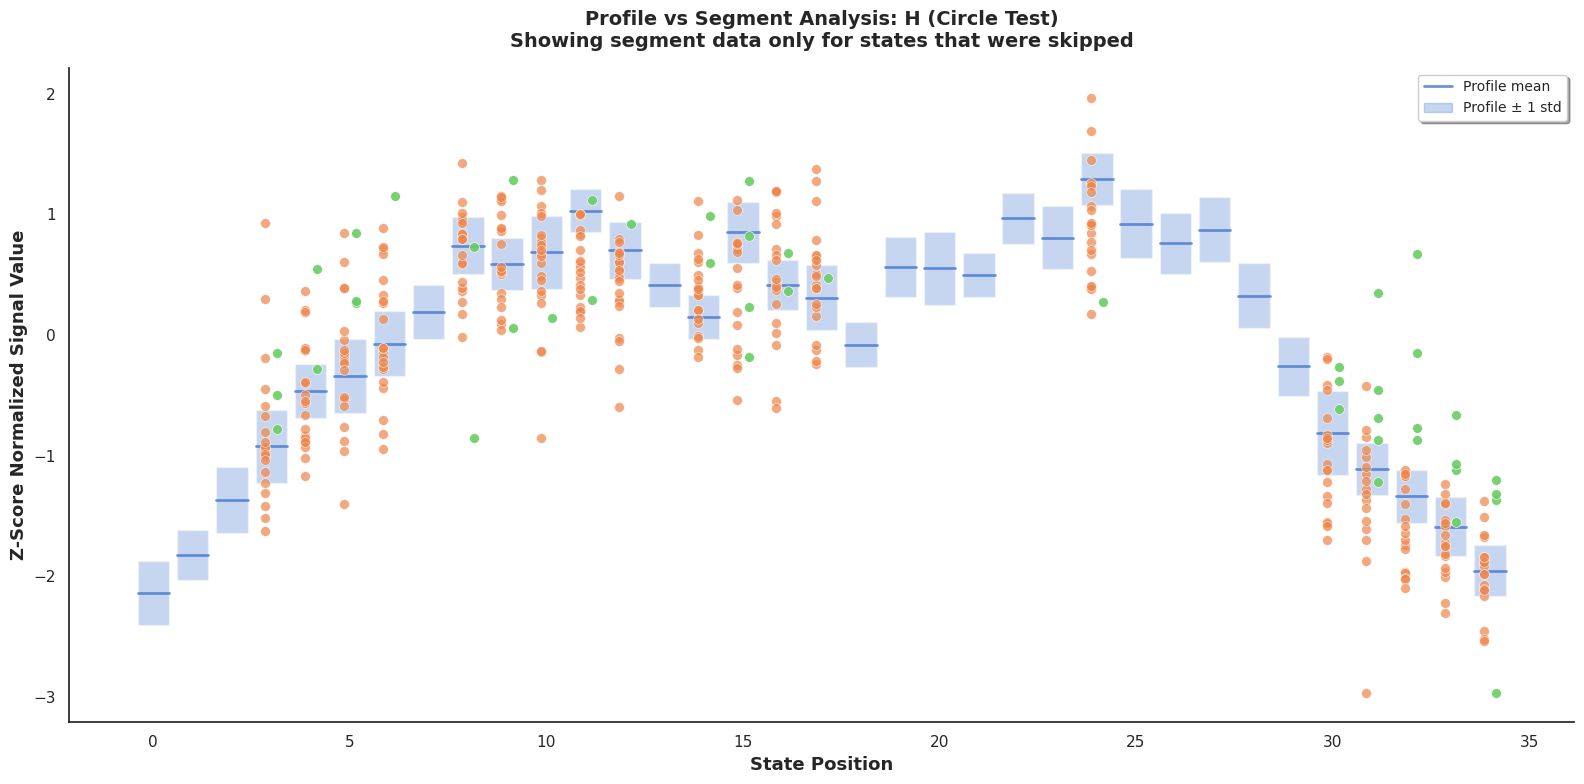

In [11]:
# Cell 10: Create profile skip analysis plot
fig = plotter.plot_profile_skip_analysis(
    segment_range=(0, 34), 
    figsize=(16, 8),
    use_normalized=True
)
plt.savefig('figures/c_profile_skip_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Cell 11: Find and plot skipped states within profile
within_profile = analyzer.find_skips_within_profile(segment_range=(0, 34))

if within_profile:
    print(f"\nFound {len(within_profile)} skipped states within profile std:")
    
    for skip in within_profile[:10]:
        print(f"  {skip['trace_id']}: State {skip['state_pos']}, "
              f"deviation = {skip['deviation']:.2f}σ")
    
    plotter.plot_individual_skip_details(within_profile, max_plots=10)
else:
    print("No skipped states found within profile standard deviation")


Finding skipped states within profile standard deviation...

Analyzing skip patterns for segment range (0, 34)
Completed skip pattern analysis for 22 traces
Total states skipped in circle tests: 47
Total states skipped in misclassified: 47
Found 11 skipped states within profile std

Found 11 skipped states within profile std:
  20221011_run02_a_254.0_3531_H: State 31, deviation = 0.51σ
  20220824_run02_a_457.0_633_H: State 4, deviation = 0.80σ
  20220824_run02_a_382.0_493_H: State 8, deviation = 0.04σ
  20220824_run02_a_382.0_493_H: State 30, deviation = 0.56σ
  20221108_run01_a_235.0_4323_H: State 11, deviation = 0.49σ
  20221108_run01_a_235.0_4323_H: State 12, deviation = 0.90σ
  20221011_run02_a_237.0_3545_H: State 16, deviation = 0.24σ
  20220824_run02_a_469.0_675_H: State 33, deviation = 0.17σ
  20221011_run02_a_295.0_3615_H: State 3, deviation = 0.47σ
  20221011_run02_a_340.0_3657_H: State 15, deviation = 0.13σ

Creating 10 detailed skip plots...
  Saved: figures/skip_details/sk

## KDE Distribution Analysis

For traces where states were skipped in the circle test, we'll compare:
1. The actual segment signal distributions
2. The profile for the correct amino acid
3. The profile for the incorrectly predicted amino acid

This helps us understand why the HMM might prefer the wrong amino acid.

In [ ]:
# Cell 12: Prepare KDE comparison data (filtered)
kde_comparison_data = analyzer.prepare_kde_comparison_data(within_profile)

if kde_comparison_data:
    print(f"\nFound {len(kde_comparison_data)} states skipped in circle but matched in misclassified:")
    for data in kde_comparison_data:
        print(f"  {data['trace_id']}: State {data['state_pos']}, "
              f"{data['true_aa']} -> {data['pred_aa']}")
else:
    print("\nNo states found that were skipped in circle but matched in misclassified")

In [ ]:
# Cell 13: Create path statistics table
if kde_comparison_data:
    stats_table = analyzer.create_path_statistics_table(kde_comparison_data)
    
    print("\nPath Statistics Comparison:")
    print(stats_table.to_string(index=False))
    
    stats_table.to_csv('figures/path_statistics_comparison.csv', index=False)
    print("\nTable saved to figures/path_statistics_comparison.csv")

In [ ]:
# Cell 14: Create grouped path comparison plots (one per trace)
if kde_comparison_data:
    plotter.plot_detailed_path_comparison_grouped(kde_comparison_data)

In [ ]:
# Cell 15: Create individual KDE comparison plots (one per state)
if kde_comparison_data:
    plotter.plot_kde_comparisons(kde_comparison_data, max_plots=20)

### KDE Analysis Observations:

[Add your observations here]
- Do the segment distributions align better with true or predicted profiles?
- Are there systematic biases?
- Which traces show the most disagreement?

### AA-pair specific focus

In [ ]:
# Cell 11: Focus on specific confusion pair - C misclassified as K
c_to_k = [d for d in kde_data if d['true_aa'] == 'C' and d['predicted_aa'] == 'K']

if c_to_k:
    print(f"Found {len(c_to_k)} C->K misclassifications with skipped states")
    
    fig_c_k = plotter.plot_kde_pileup(c_to_k, max_cols=3, figsize_per_subplot=(5, 3))
    plt.suptitle('C misclassified as K: Detailed KDE Analysis', fontsize=16, y=1.02)
    plt.savefig('figures/c_to_k_kde_detail.png', dpi=300, bbox_inches='tight')
    plt.show()

## Log Probability Analysis

Compare the log probabilities between circle test and misclassified runs to see how confident the model is in each case.

In [ ]:
# Cell 12: Log probability comparison
fig_logprob = plotter.plot_log_probability_comparison(figsize=(12, 5))
plt.savefig('figures/c_d_logprob_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 13: Statistical summary of log probabilities
import numpy as np

circle_probs = [d['circle_test']['log_probability'] 
                for d in analyzer.matched_data.values()]
misclass_probs = [d['misclassified']['log_probability'] 
                  for d in analyzer.matched_data.values()]

print("Log Probability Statistics:")
print(f"\nCircle Test:")
print(f"  Mean: {np.mean(circle_probs):.2f}")
print(f"  Std: {np.std(circle_probs):.2f}")
print(f"  Range: [{np.min(circle_probs):.2f}, {np.max(circle_probs):.2f}]")

print(f"\nMisclassified:")
print(f"  Mean: {np.mean(misclass_probs):.2f}")
print(f"  Std: {np.std(misclass_probs):.2f}")
print(f"  Range: [{np.min(misclass_probs):.2f}, {np.max(misclass_probs):.2f}]")

print(f"\nMean difference: {np.mean(misclass_probs) - np.mean(circle_probs):.2f}")

## Deep Dive: Worst Performers

Let's examine the traces with the largest log probability drops (circle test to misclassified).

In [ ]:
# Cell 15: Find worst performers
logprob_drops = []
for trace_id, data in analyzer.matched_data.items():
    circle_lp = data['circle_test']['log_probability']
    misclass_lp = data['misclassified']['log_probability']
    drop = circle_lp - misclass_lp
    
    logprob_drops.append({
        'trace_id': trace_id,
        'true_aa': trace_id.split('_')[-1],
        'pred_aa': data['misclassified']['predicted_category'],
        'circle_logprob': circle_lp,
        'misclass_logprob': misclass_lp,
        'drop': drop
    })

df_drops = pd.DataFrame(logprob_drops)
df_drops = df_drops.sort_values('drop', ascending=False)

print("Top 10 worst performers (largest log probability drops):")
print(df_drops.head(10).to_string(index=False))

In [ ]:
# Cell 16: Investigate specific trace
worst_trace_id = df_drops.iloc[0]['trace_id']
worst_analysis = skip_analysis[worst_trace_id]

print(f"Detailed analysis of worst performer: {worst_trace_id}")
print(f"True AA: {worst_analysis['true_aa']}")
print(f"Predicted AA: {worst_analysis['predicted_aa']}")
print(f"\nCircle test path length: {len(worst_analysis['circle_path'])}")
print(f"Misclassified path length: {len(worst_analysis['misclass_path'])}")
print(f"\nStates skipped in circle test: {worst_analysis['circle_skipped']}")
print(f"States skipped in misclassified: {worst_analysis['misclass_skipped']}")
print(f"States skipped in both: {worst_analysis['both_skipped']}")